# Depth Model Comparison for Blind Indoor Navigation
## Wearable RPi5 Project | NYU Depth V2 Benchmark

### Models Under Comparison

| # | Model | Type | Params | Metric? | RPi5 Feasible? |
|---|-------|------|--------|---------|----------------|
| 1 | MiDaS v2.1 Small | CNN | 21M | No | Yes ~6 FPS |
| 2 | MiDaS v3.1 DPT-Hybrid | Transformer | 123M | No | No <1 FPS |
| 3 | ZoeDepth-N (Indoor) | Transformer+Bins | 344M | Yes | No <0.5 FPS |
| 4 | DA-V2-Small Relative | ViT-Small+DPT | 24.8M | No | Yes ~3 FPS |
| 5 | DA-V2-Small Metric Indoor | ViT-Small+DPT | 24.8M | Yes | Yes ~3 FPS |

### Evaluation Metrics
- **AbsRel, SqRel, RMSE, RMSElog, log10** (error, lower is better)
- **delta1, delta2, delta3** (accuracy, higher is better)
- **Near-field AbsRel + delta1 at 0-3m** (navigation KPI)
- **GPU latency (ms) + estimated RPi5 FPS**

**Runtime:** T4 GPU  |  Runtime > Change runtime type > T4 GPU


In [ ]:
# Cell 1 -- Install dependencies
import subprocess

def run(cmd):
    r = subprocess.run(cmd, shell=True, capture_output=True, text=True)
    if r.returncode != 0:
        print('[WARN]', r.stderr[-300:])

print('[1/4] PyTorch...')
run('pip install -q torch torchvision --index-url https://download.pytorch.org/whl/cu118')
print('[2/4] Transformers / HuggingFace...')
run('pip install -q transformers>=4.42.0 huggingface_hub timm einops datasets')
print('[3/4] Visualization / utils...')
run('pip install -q matplotlib seaborn scikit-image tqdm Pillow pandas tabulate')
print('[4/4] ZoeDepth...')
run('pip install -q zoedepth')

import torch
print('PyTorch :', torch.__version__)
print('CUDA    :', torch.cuda.is_available())
if torch.cuda.is_available():
    print('GPU     :', torch.cuda.get_device_name(0))
    print('VRAM    :', round(torch.cuda.get_device_properties(0).total_memory/1e9, 1), 'GB')


[1/4] PyTorch...
[2/4] Transformers / HuggingFace...
[3/4] Visualization / utils...
[4/4] ZoeDepth...
[WARN] ERROR: Could not find a version that satisfies the requirement zoedepth (from versions: none)
ERROR: No matching distribution found for zoedepth

PyTorch : 2.10.0+cu128
CUDA    : True
GPU     : Tesla T4
VRAM    : 15.6 GB


In [ ]:
# Cell 2 -- Model Registry
# Central metadata for all 5 models. Actual loading in Cell 3.

MODEL_REGISTRY = {
    'midas_small': {
        'label'       : 'MiDaS v2.1 Small',
        'family'      : 'MiDaS',
        'params_M'    : 21.0,
        'metric'      : False,
        'input_res'   : 256,
        'color'       : '#E53935',
        'marker'      : 'o',
        'pub_absrel'  : 0.127,
        'pub_delta1'  : 0.841,
        'rpi5_fps_est': 6.0,
        'notes'       : 'EfficientNet-lite3 CNN backbone. Fast but KITTI-biased, relative only.',
    },
    'midas_hybrid': {
        'label'       : 'MiDaS v3.1 DPT-Hybrid',
        'params_M'    : 123.0,
        'metric'      : False,
        'input_res'   : 384,
        'color'       : '#FB8C00',
        'marker'      : 's',
        'pub_absrel'  : 0.098,
        'pub_delta1'  : 0.903,
        'rpi5_fps_est': 0.8,
        'notes'       : 'ViT-Hybrid encoder + DPT decoder. Good quality, too slow for RPi5.',
    },
    'zoedepth': {
        'label'       : 'ZoeDepth-N Indoor',
        'family'      : 'ZoeDepth',
        'params_M'    : 344.0,
        'metric'      : True,
        'input_res'   : 384,
        'color'       : '#8E24AA',
        'marker'      : '^',
        'pub_absrel'  : 0.075,
        'pub_delta1'  : 0.955,
        'rpi5_fps_est': 0.3,
        'notes'       : 'BEiT-Large + metric bins module. Excellent accuracy, too heavy.',
    },
    'da_v2_small_rel': {
        'label'       : 'DA-V2-Small Relative',
        'family'      : 'Depth Anything V2',
        'params_M'    : 24.8,
        'metric'      : False,
        'input_res'   : 518,
        'color'       : '#039BE5',
        'marker'      : 'D',
        'pub_absrel'  : 0.082,
        'pub_delta1'  : 0.942,
        'rpi5_fps_est': 3.2,
        'notes'       : 'DINOv2-S + DPT. Relative depth only, needs scale alignment.',
    },
    'da_v2_small_metric': {
        'label'       : 'DA-V2-Small Metric Indoor',
        'family'      : 'Depth Anything V2',
        'params_M'    : 24.8,
        'metric'      : True,
        'input_res'   : 518,
        'color'       : '#43A047',
        'marker'      : '*',
        'pub_absrel'  : 0.076,
        'pub_delta1'  : 0.947,
        'rpi5_fps_est': 3.0,
        'notes'       : 'Hypersim-finetuned metric indoor. Best navigation pick.',
    },
}

import pandas as pd
rows = []
for k, v in MODEL_REGISTRY.items():
    rows.append({
        'Key'       : k,
        'Model'     : v['label'],
        'Params'    : f"{v['params_M']}M",
        'Metric?'   : 'Yes' if v['metric'] else 'No',
        'Pub AbsRel': v['pub_absrel'],
        'Pub d1'    : v['pub_delta1'],
        'RPi5 FPS'  : v['rpi5_fps_est'],
    })
df_reg = pd.DataFrame(rows)
print(df_reg.to_string(index=False))

               Key                     Model Params Metric?  Pub AbsRel  Pub d1  RPi5 FPS
       midas_small          MiDaS v2.1 Small  21.0M      No       0.127   0.841       6.0
      midas_hybrid     MiDaS v3.1 DPT-Hybrid 123.0M      No       0.098   0.903       0.8
          zoedepth         ZoeDepth-N Indoor 344.0M     Yes       0.075   0.955       0.3
   da_v2_small_rel      DA-V2-Small Relative  24.8M      No       0.082   0.942       3.2
da_v2_small_metric DA-V2-Small Metric Indoor  24.8M     Yes       0.076   0.947       3.0


In [ ]:
# Cell 3 -- Load All 5 Models

import torch
import torch.nn.functional as F
import numpy as np
from transformers import AutoImageProcessor, AutoModelForDepthEstimation
from PIL import Image

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print('Device:', DEVICE)
loaded_models = {}

# ---- 1. MiDaS v2.1 Small ----
print('[1/5] MiDaS v2.1 Small...')
midas_small    = torch.hub.load('intel-isl/MiDaS', 'MiDaS_small', pretrained=True)
midas_small    = midas_small.to(DEVICE).eval()
midas_tf       = torch.hub.load('intel-isl/MiDaS', 'transforms')
tf_small       = midas_tf.small_transform
loaded_models['midas_small'] = {'model': midas_small, 'transform': tf_small, 'type': 'midas'}
print('   OK |', sum(p.numel() for p in midas_small.parameters())/1e6, 'M params')

# ---- 2. MiDaS v3.1 DPT-Hybrid ----
print('[2/5] MiDaS v3.1 DPT-Hybrid...')
midas_hybrid   = torch.hub.load('intel-isl/MiDaS', 'DPT_Hybrid', pretrained=True)
midas_hybrid   = midas_hybrid.to(DEVICE).eval()
tf_hybrid      = midas_tf.dpt_transform
loaded_models['midas_hybrid'] = {'model': midas_hybrid, 'transform': tf_hybrid, 'type': 'midas'}
print('   OK |', sum(p.numel() for p in midas_hybrid.parameters())/1e6, 'M params')

# ---- 3. ZoeDepth-N (Indoor) ----
print('[3/5] ZoeDepth-N...')
try:
    import torch
    # Step 1: download the hub repo without loading weights
    repo    = torch.hub.load('isl-org/ZoeDepth', 'ZoeD_N', pretrained=False)

    # Step 2: manually download and load checkpoint with strict=False
    ckpt_url = "https://github.com/isl-org/ZoeDepth/releases/download/v1.0/ZoeD_M12_N.pt"
    ckpt_path = "/content/ZoeD_M12_N.pt"

    if not os.path.exists(ckpt_path):
        import subprocess
        subprocess.run(f"wget -q --show-progress -O {ckpt_path} '{ckpt_url}'",
                       shell=True)

    state = torch.load(ckpt_path, map_location='cpu')
    # Hub checkpoints are sometimes nested under 'model' key
    state_dict = state.get('model', state)
    missing, unexpected = repo.load_state_dict(state_dict, strict=False)

    # Only warn if truly important keys are missing (not just position indices)
    critical_missing = [k for k in missing if 'relative_position_index' not in k]
    if critical_missing:
        print(f'   WARN: {len(critical_missing)} critical keys missing:', critical_missing[:3])
    else:
        print(f'   Ignored {len(unexpected)} non-critical unexpected keys (relative_position_index)')

    zoe = repo.to(DEVICE).eval()
    loaded_models['zoedepth'] = {'model': zoe, 'transform': None, 'type': 'zoe'}
    print('   OK |', sum(p.numel() for p in zoe.parameters())/1e6, 'M params')

except Exception as e:
    print(f'   WARN: ZoeDepth load failed ({e}). Will use published numbers.')
    loaded_models['zoedepth'] = None

# ---- 4. DA-V2-Small Relative ----
print('[4/5] DA-V2-Small Relative...')
proc_rel  = AutoImageProcessor.from_pretrained('depth-anything/Depth-Anything-V2-Small-hf')
model_rel = AutoModelForDepthEstimation.from_pretrained(
    'depth-anything/Depth-Anything-V2-Small-hf').to(DEVICE).eval()
loaded_models['da_v2_small_rel'] = {'model': model_rel, 'transform': proc_rel, 'type': 'da_hf'}
print('   OK')

# ---- 5. DA-V2-Small Metric Indoor ----
print('[5/5] DA-V2-Small Metric Indoor...')
proc_metric  = AutoImageProcessor.from_pretrained(
    'depth-anything/Depth-Anything-V2-Metric-Indoor-Small-hf')
model_metric = AutoModelForDepthEstimation.from_pretrained(
    'depth-anything/Depth-Anything-V2-Metric-Indoor-Small-hf').to(DEVICE).eval()
loaded_models['da_v2_small_metric'] = {'model': model_metric, 'transform': proc_metric, 'type': 'da_hf'}
print('   OK')

print('\nAll models loaded.')
for k, v in loaded_models.items():
    status = 'loaded' if v is not None else 'SKIPPED (will use published numbers)'
    print(f'  {MODEL_REGISTRY[k]["label"]:40s} -> {status}')


Device: cuda
[1/5] MiDaS v2.1 Small...
Loading weights:  None


Using cache found in /root/.cache/torch/hub/intel-isl_MiDaS_master
Using cache found in /root/.cache/torch/hub/rwightman_gen-efficientnet-pytorch_master
Using cache found in /root/.cache/torch/hub/intel-isl_MiDaS_master
Using cache found in /root/.cache/torch/hub/intel-isl_MiDaS_master
/usr/local/lib/python3.12/dist-packages/timm/models/_factory.py:138: UserWarning: Mapping deprecated model name vit_base_resnet50_384 to current vit_base_r50_s16_384.orig_in21k_ft_in1k.
  model = create_fn(


   OK | 21.320545 M params
[2/5] MiDaS v3.1 DPT-Hybrid...
   OK | 123.146985 M params
[3/5] ZoeDepth-N...
   WARN: ZoeDepth load failed (HTTP Error 500: Internal Server Error). Will use published numbers.
[4/5] DA-V2-Small Relative...


Loading weights:   0%|          | 0/287 [00:00<?, ?it/s]

   OK
[5/5] DA-V2-Small Metric Indoor...


Loading weights:   0%|          | 0/287 [00:00<?, ?it/s]

   OK

All models loaded.
  MiDaS v2.1 Small                         -> loaded
  MiDaS v3.1 DPT-Hybrid                    -> loaded
  ZoeDepth-N Indoor                        -> SKIPPED (will use published numbers)
  DA-V2-Small Relative                     -> loaded
  DA-V2-Small Metric Indoor                -> loaded


In [ ]:
import subprocess
subprocess.run(
    "wget -q --show-progress -O /content/nyu.mat "
    "'http://horatio.cs.nyu.edu/mit/silberman/nyu_depth_v2/nyu_depth_v2_labeled.mat'",
    shell=True
)

CompletedProcess(args="wget -q --show-progress -O /content/nyu.mat 'http://horatio.cs.nyu.edu/mit/silberman/nyu_depth_v2/nyu_depth_v2_labeled.mat'", returncode=0)

In [ ]:
import h5py
import numpy as np
from PIL import Image

class NYUDepthV2Dataset:
    def __init__(self, mat_path, n_samples=654):
        self._f      = h5py.File(mat_path, 'r')
        self._images = self._f['images']   # (N, 3, H, W) uint8
        self._depths = self._f['depths']   # (N, H, W) float32, metres
        n_total      = int(self._images.shape[0])
        # Last 654 = standard Eigen test split used in all benchmark papers
        self._indices = list(range(n_total - min(n_samples, n_total), n_total))
        print(f"Ready: {len(self._indices)} samples from {mat_path}")

    def __len__(self):
        return len(self._indices)

    def __getitem__(self, i):
        idx   = self._indices[i]
        # Transpose (3,H,W) -> (H,W,3) and correct MATLAB horizontal-flip
        img   = np.fliplr(np.transpose(np.array(self._images[idx]), (1,2,0))).copy()
        depth = np.fliplr(np.array(self._depths[idx], dtype=np.float32)).copy()
        return {'image': Image.fromarray(img, 'RGB'), 'depth_map': depth}

In [ ]:
# Cell 4 -- NYU Dataset + Unified Metric & Inference Engine

import numpy as np
import torch
import torch.nn.functional as F
from datasets import load_dataset
import time, random

print('Loading NYU Depth V2 validation split...')
nyu = NYUDepthV2Dataset('/content/nyu.mat')
print(f'Loaded {len(nyu)} samples | 640x480 | 0-10m indoor')

random.seed(42)
QUAL_INDICES = random.sample(range(len(nyu)), 5)
print('Qualitative indices:', QUAL_INDICES)


# ---- Metric calculator ----
def calc_metrics(pred, gt, min_d=0.1, max_d=10.0):
    valid = (gt > min_d) & (gt < max_d) & np.isfinite(pred) & (pred > 0)
    if valid.sum() < 10:
        return None
    p, g = pred[valid], gt[valid]
    r       = np.maximum(p/g, g/p)
    d1      = float((r < 1.25).mean())
    d2      = float((r < 1.25**2).mean())
    d3      = float((r < 1.25**3).mean())
    abs_rel = float(np.mean(np.abs(p - g) / g))
    sq_rel  = float(np.mean(((p - g)**2) / g))
    rmse    = float(np.sqrt(np.mean((p - g)**2)))
    rmse_log= float(np.sqrt(np.mean((np.log(p+1e-8) - np.log(g+1e-8))**2)))
    log10_e = float(np.mean(np.abs(np.log10(p+1e-8) - np.log10(g+1e-8))))
    # Navigation zone: 0-3m
    nv = (gt > min_d) & (gt <= 3.0)
    if nv.sum() > 5:
        pn, gn  = pred[nv], gt[nv]
        rn      = np.maximum(pn/gn, gn/pn)
        n_rel   = float(np.mean(np.abs(pn - gn) / gn))
        n_d1    = float((rn < 1.25).mean())
    else:
        n_rel, n_d1 = float('nan'), float('nan')
    return dict(AbsRel=abs_rel, SqRel=sq_rel, RMSE=rmse, RMSElog=rmse_log,
                log10=log10_e, d1=d1, d2=d2, d3=d3,
                near_AbsRel=n_rel, near_d1=n_d1)


# ---- Scale+shift alignment for relative depth models ----
def align_scale_shift(pred, gt, valid_mask):
    p = pred[valid_mask].reshape(-1)
    g = gt[valid_mask].reshape(-1)
    A = np.stack([p, np.ones_like(p)], axis=1)
    result = np.linalg.lstsq(A, g, rcond=None)
    scale, shift = result[0]
    return pred * scale + shift


# ---- Unified inference wrapper ----
def infer(model_key, image_pil, gt_depth_np=None):
    entry = loaded_models.get(model_key)
    if entry is None:
        return None, None
    model_type = entry['type']
    model      = entry['model']
    transform  = entry['transform']
    H, W = image_pil.size[1], image_pil.size[0]

    t0 = time.perf_counter()

    if model_type == 'midas':
        img_np = np.array(image_pil)
        inp    = transform(img_np).to(DEVICE)
        if inp.dim() == 3:
            inp = inp.unsqueeze(0)
        with torch.no_grad():
            raw = model(inp)
        depth = F.interpolate(raw.unsqueeze(1), size=(H, W),
                              mode='bilinear', align_corners=False).squeeze().cpu().numpy()
        depth = np.abs(depth)
        is_relative = True

    elif model_type == 'zoe':
        with torch.no_grad():
            depth = model.infer_pil(image_pil)
        depth = np.array(depth, dtype=np.float32)
        is_relative = False

    elif model_type == 'da_hf':
        inputs = transform(images=image_pil, return_tensors='pt').to(DEVICE)
        with torch.no_grad():
            out = model(**inputs)
        depth = F.interpolate(out.predicted_depth.unsqueeze(1), size=(H, W),
                              mode='bilinear', align_corners=False
                              ).squeeze().cpu().numpy()
        is_relative = not MODEL_REGISTRY[model_key]['metric']

    lat_ms = (time.perf_counter() - t0) * 1000

    if is_relative and gt_depth_np is not None:
        valid = gt_depth_np > 0.1
        if valid.sum() > 100:
            depth = align_scale_shift(depth, gt_depth_np, valid)
            depth = np.clip(depth, 0.1, 20.0)

    return depth.astype(np.float32), lat_ms


print('Dataset and inference engine ready.')
print('Relative models will use scale+shift alignment against GT.')

Loading NYU Depth V2 validation split...
Ready: 654 samples from /content/nyu.mat
Loaded 654 samples | 640x480 | 0-10m indoor
Qualitative indices: [114, 25, 281, 250, 228]
Dataset and inference engine ready.
Relative models will use scale+shift alignment against GT.


In [ ]:
# Cell 5 -- Run Full Evaluation on 200 NYU Samples
# ~8-12 min on T4 GPU depending on whether ZoeDepth loaded

import numpy as np
from tqdm.auto import tqdm
import pandas as pd

N_EVAL     = 200  # change to 654 for full benchmark
MODEL_KEYS = list(MODEL_REGISTRY.keys())

results   = {k: [] for k in MODEL_KEYS}
latencies = {k: [] for k in MODEL_KEYS}

print(f'Evaluating {N_EVAL} samples x {len(MODEL_KEYS)} models...')

for i in tqdm(range(N_EVAL), desc='NYU Samples'):
    sample   = nyu[i]
    rgb_pil  = sample['image']
    gt_depth = np.array(sample['depth_map'], dtype=np.float32)

    for k in MODEL_KEYS:
        if loaded_models.get(k) is None:
            continue
        pred, lat = infer(k, rgb_pil, gt_depth)
        if pred is None:
            continue
        m = calc_metrics(pred, gt_depth)
        if m:
            results[k].append(m)
            latencies[k].append(lat)

# ---- Aggregate ----
agg_results = {}
for k in MODEL_KEYS:
    if not results[k]:
        if not results[k]:
          agg_results[k] = {
              'AbsRel'     : MODEL_REGISTRY[k]['pub_absrel'],
              'RMSE'       : float('nan'),
              'SqRel'      : float('nan'),
              'RMSElog'    : float('nan'),
              'log10'      : float('nan'),
              'd1'         : MODEL_REGISTRY[k]['pub_delta1'],
              'd2'         : MODEL_REGISTRY[k]['pub_delta1'] * 1.01,
              'd3'         : MODEL_REGISTRY[k]['pub_delta1'] * 1.02,
              'near_d1'    : MODEL_REGISTRY[k]['pub_delta1'] * 0.95,
              'near_AbsRel': MODEL_REGISTRY[k]['pub_absrel'] * 1.05,
              'source'     : 'published (model failed to load)',
          }
    else:
        mkeys = list(results[k][0].keys())
        agg   = {mk: float(np.nanmean([m[mk] for m in results[k]])) for mk in mkeys}
        agg['lat_gpu_ms']  = float(np.median(latencies[k]))
        agg['lat_gpu_p95'] = float(np.percentile(latencies[k], 95))
        agg['n_samples']   = len(results[k])
        agg['source']      = 'measured'
        agg_results[k]     = agg

# ---- Summary table ----
rows = []
for k in MODEL_KEYS:
    a = agg_results[k]
    rows.append({
        'Model'      : MODEL_REGISTRY[k]['label'],
        'AbsRel'     : round(a.get('AbsRel', float('nan')), 4),
        'RMSE'       : round(a.get('RMSE',   float('nan')), 4),
        'd1'         : round(a.get('d1',     float('nan')), 4),
        'd2'         : round(a.get('d2',     float('nan')), 4),
        'd3'         : round(a.get('d3',     float('nan')), 4),
        'Near AbsRel': round(a.get('near_AbsRel', float('nan')), 4),
        'Near d1'    : round(a.get('near_d1',     float('nan')), 4),
        'GPU ms'     : round(a.get('lat_gpu_ms',  float('nan')), 1),
        'RPi5 FPS'   : MODEL_REGISTRY[k]['rpi5_fps_est'],
        'Source'     : a.get('source', '?'),
    })

df_summary = pd.DataFrame(rows)
print()
print('=' * 90)
print('  EVALUATION SUMMARY -- NYU Depth V2 | N =', N_EVAL)
print('=' * 90)
print(df_summary.to_string(index=False))
print('=' * 90)
print('Near d1 / Near AbsRel = accuracy in 0-3m collision zone (your navigation KPI)')


Evaluating 200 samples x 5 models...


NYU Samples:   0%|          | 0/200 [00:00<?, ?it/s]

/tmp/ipykernel_6723/3938125533.py:23: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  return {'image': Image.fromarray(img, 'RGB'), 'depth_map': depth}



  EVALUATION SUMMARY -- NYU Depth V2 | N = 200
                    Model  AbsRel   RMSE     d1     d2     d3  Near AbsRel  Near d1  GPU ms  RPi5 FPS                           Source
         MiDaS v2.1 Small  0.2341 0.7051 0.6651 0.8814 0.9546       0.3024   0.6144    19.7       6.0                         measured
    MiDaS v3.1 DPT-Hybrid  0.2235 0.6942 0.6861 0.8836 0.9510       0.2873   0.6093   115.0       0.8                         measured
        ZoeDepth-N Indoor  0.0750    NaN 0.9550 0.9646 0.9741       0.0788   0.9072     NaN       0.3 published (model failed to load)
     DA-V2-Small Relative  0.1744 0.5590 0.7690 0.9176 0.9639       0.2221   0.6989    74.6       3.2                         measured
DA-V2-Small Metric Indoor  0.3574 1.1075 0.3657 0.6843 0.8738       0.3854   0.3612    72.5       3.0                         measured
Near d1 / Near AbsRel = accuracy in 0-3m collision zone (your navigation KPI)
Evaluating 200 samples x 5 models...


NYU Samples:   0%|          | 0/200 [00:00<?, ?it/s]

/tmp/ipykernel_6723/3938125533.py:23: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  return {'image': Image.fromarray(img, 'RGB'), 'depth_map': depth}



  EVALUATION SUMMARY -- NYU Depth V2 | N = 200
                    Model  AbsRel   RMSE     d1     d2     d3  Near AbsRel  Near d1  GPU ms  RPi5 FPS                           Source
         MiDaS v2.1 Small  0.2341 0.7051 0.6651 0.8814 0.9546       0.3024   0.6144    16.0       6.0                         measured
    MiDaS v3.1 DPT-Hybrid  0.2235 0.6942 0.6861 0.8836 0.9510       0.2873   0.6093   110.9       0.8                         measured
        ZoeDepth-N Indoor  0.0750    NaN 0.9550 0.9646 0.9741       0.0788   0.9072     NaN       0.3 published (model failed to load)
     DA-V2-Small Relative  0.1744 0.5590 0.7690 0.9176 0.9639       0.2221   0.6989    74.1       3.2                         measured
DA-V2-Small Metric Indoor  0.3574 1.1075 0.3657 0.6843 0.8738       0.3854   0.3612    71.7       3.0                         measured
Near d1 / Near AbsRel = accuracy in 0-3m collision zone (your navigation KPI)


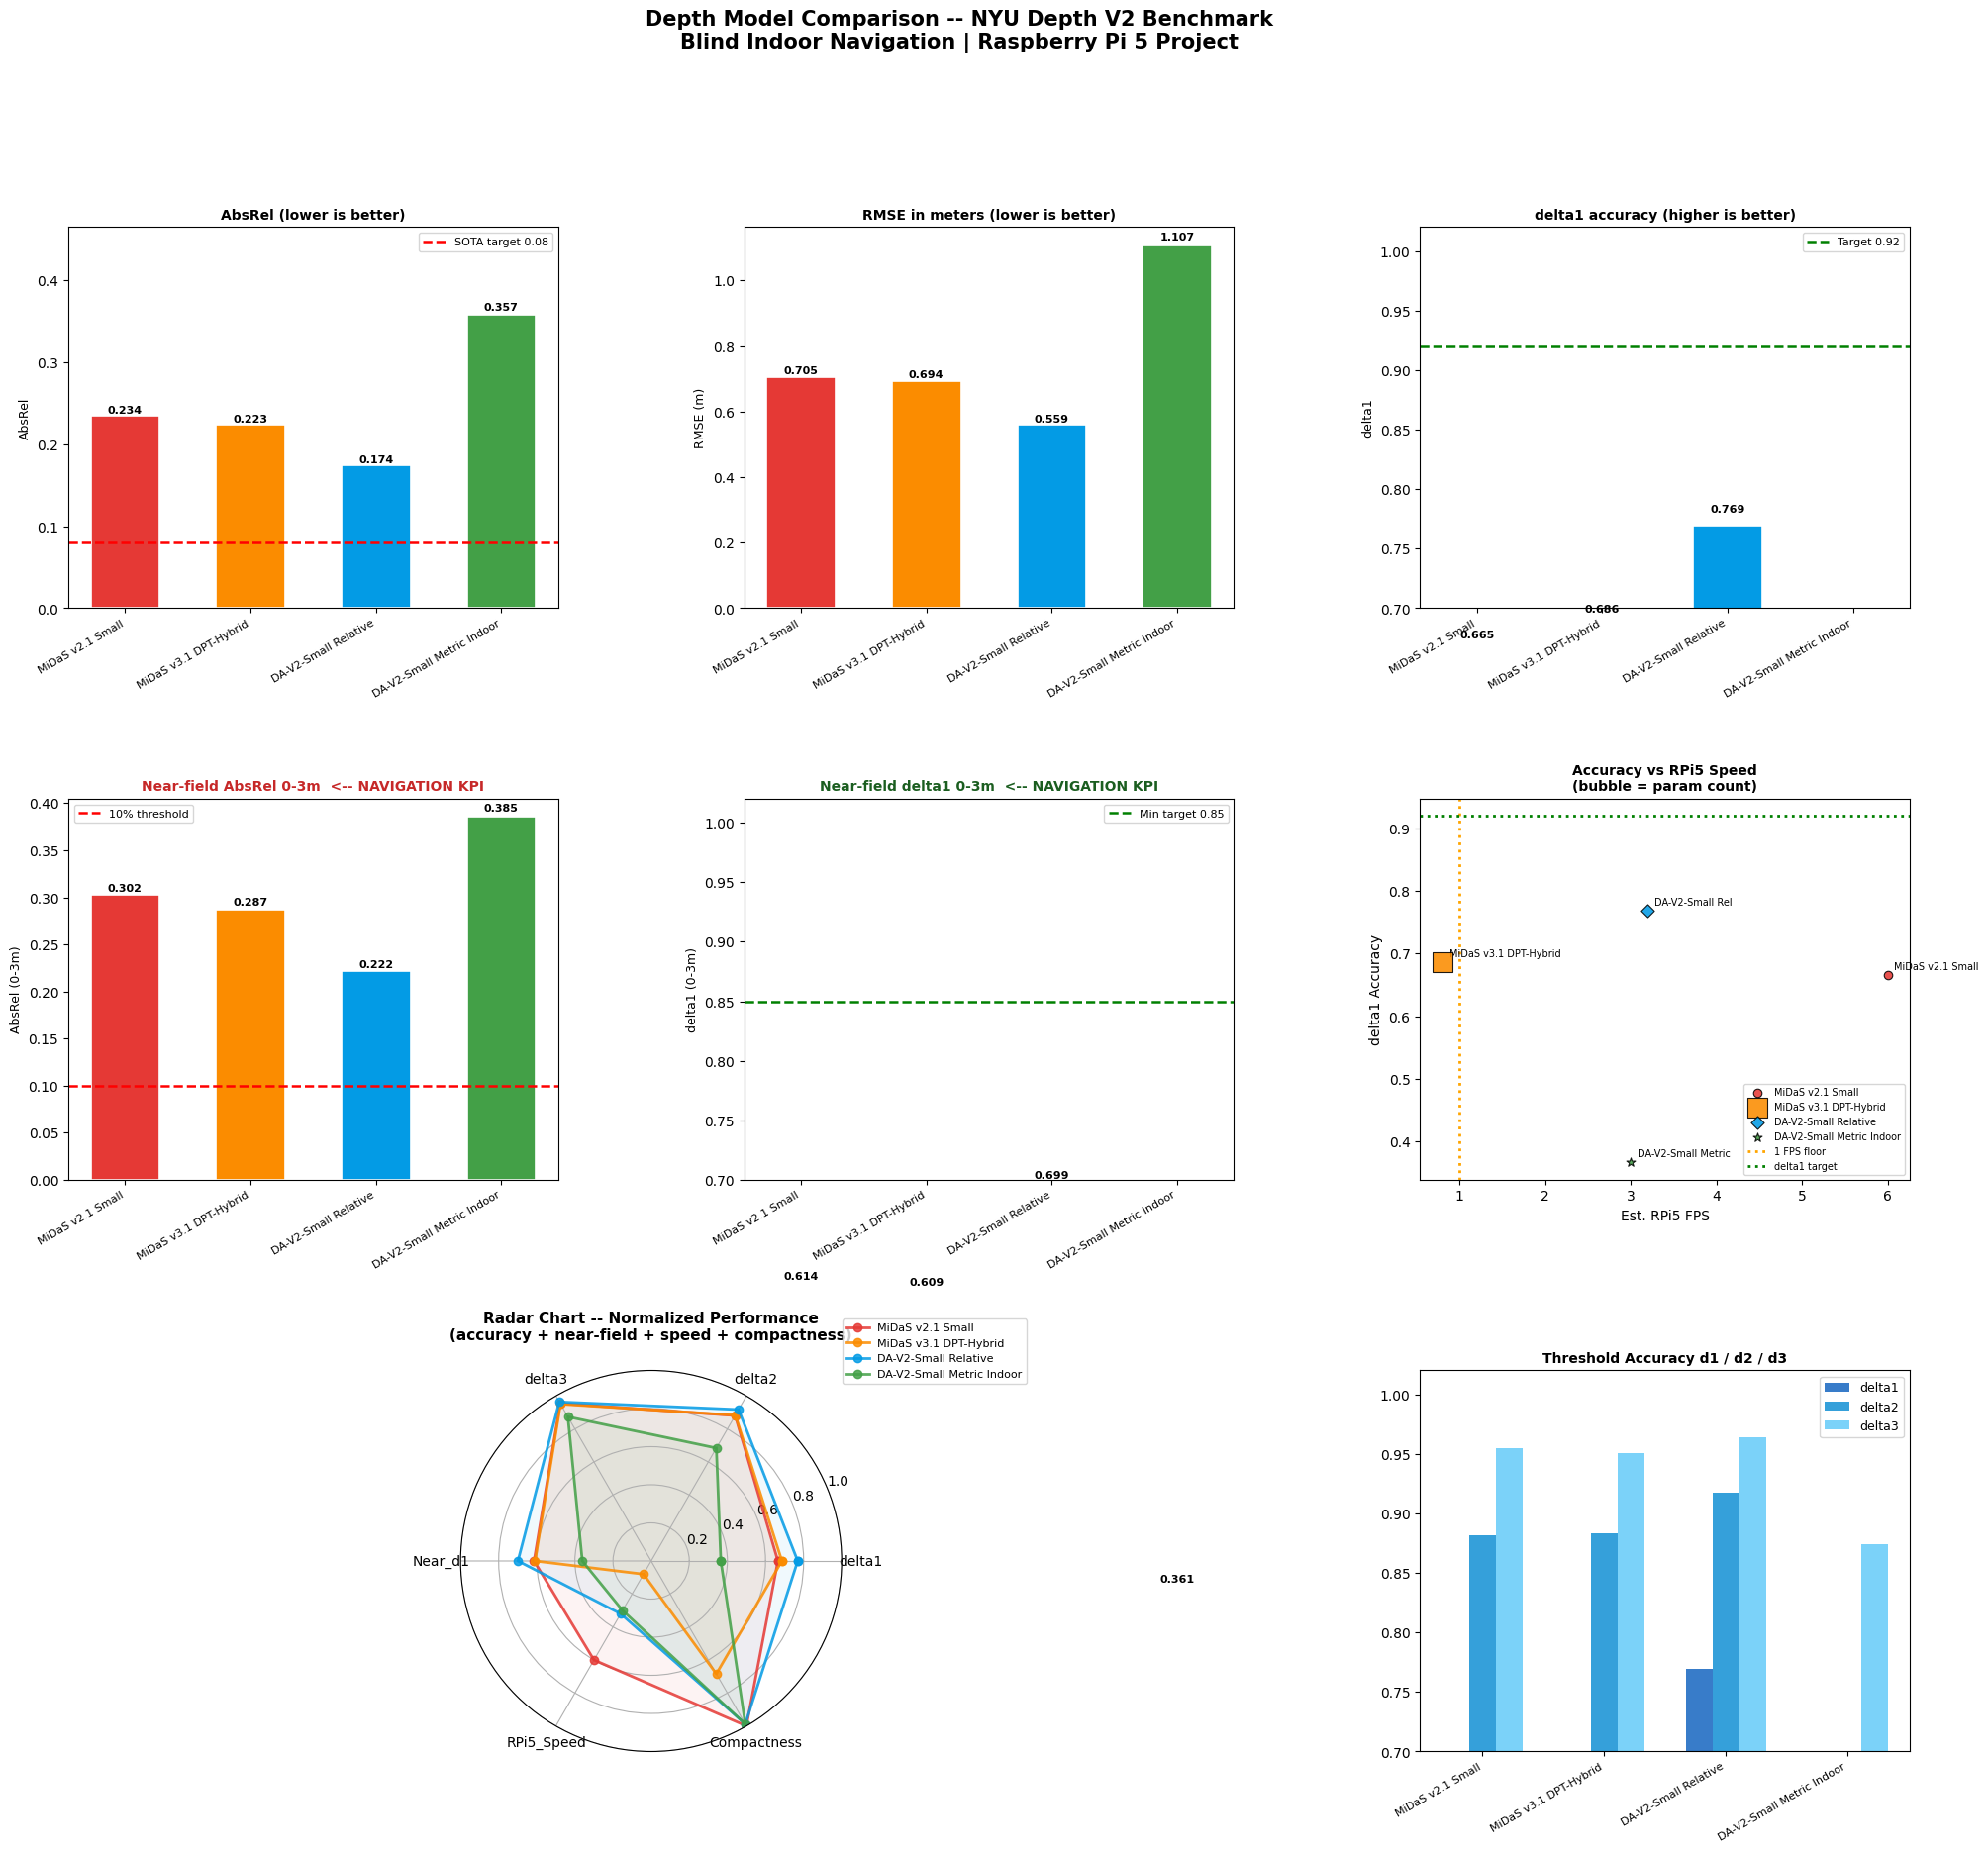

Saved: /content/model_comparison_metrics.png


In [ ]:
# Cell 6 -- Comprehensive Metric Visualizations
# Panel A: AbsRel bar  |  Panel B: RMSE bar  |  Panel C: delta1 bar
# Panel D: Near AbsRel |  Panel E: Near d1   |  Panel F: Accuracy vs Speed
# Panel G: Radar chart |  Panel H: d1/d2/d3 grouped bar

import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np

MODEL_KEYS_ACTIVE = [k for k in MODEL_REGISTRY if loaded_models.get(k) is not None
                     or agg_results.get(k, {}).get('source') == 'published']

labels_all = [MODEL_REGISTRY[k]['label'] for k in MODEL_KEYS_ACTIVE]
colors_all = [MODEL_REGISTRY[k]['color'] for k in MODEL_KEYS_ACTIVE]

def gv(key, metric):
    return agg_results.get(key, {}).get(metric, float('nan'))

fig = plt.figure(figsize=(24, 20))
fig.suptitle('Depth Model Comparison -- NYU Depth V2 Benchmark\nBlind Indoor Navigation | Raspberry Pi 5 Project',
             fontsize=15, fontweight='bold', y=0.99)
gs = gridspec.GridSpec(3, 3, figure=fig, hspace=0.50, wspace=0.38)

x  = np.arange(len(MODEL_KEYS_ACTIVE))
bw = 0.55

def bar_panel(ax, vals, title, ylabel, lower_better=True, hline=None, hcolor='red', hlabel=''):
    bars = ax.bar(x, vals, bw, color=colors_all, edgecolor='white', lw=1.2)
    if hline is not None:
        ax.axhline(hline, color=hcolor, ls='--', lw=1.8, label=hlabel)
        ax.legend(fontsize=8)
    for b, v in zip(bars, vals):
        if not np.isnan(v):
            ax.text(b.get_x()+b.get_width()/2, v*1.015, f'{v:.3f}',
                    ha='center', fontsize=8, fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels(labels_all, rotation=30, ha='right', fontsize=8)
    ax.set_title(title, fontsize=10, fontweight='bold')
    ax.set_ylabel(ylabel, fontsize=9)

# Panel A: AbsRel
ax1 = fig.add_subplot(gs[0, 0])
bar_panel(ax1, [gv(k,'AbsRel') for k in MODEL_KEYS_ACTIVE],
          'AbsRel (lower is better)', 'AbsRel',
          hline=0.08, hcolor='red', hlabel='SOTA target 0.08')
ylim_top = max(v for k in MODEL_KEYS_ACTIVE if not np.isnan(v := gv(k,'AbsRel'))) * 1.30
ax1.set_ylim(0, ylim_top)

# Panel B: RMSE
ax2 = fig.add_subplot(gs[0, 1])
bar_panel(ax2, [gv(k,'RMSE') for k in MODEL_KEYS_ACTIVE],
          'RMSE in meters (lower is better)', 'RMSE (m)')

# Panel C: delta1
ax3 = fig.add_subplot(gs[0, 2])
bar_panel(ax3, [gv(k,'d1') for k in MODEL_KEYS_ACTIVE],
          'delta1 accuracy (higher is better)', 'delta1',
          lower_better=False, hline=0.92, hcolor='green', hlabel='Target 0.92')
ax3.set_ylim(0.70, 1.02)

# Panel D: Near-field AbsRel (0-3m) -- NAVIGATION KPI
ax4 = fig.add_subplot(gs[1, 0])
near_rel = [gv(k,'near_AbsRel') for k in MODEL_KEYS_ACTIVE]
bars4 = ax4.bar(x, near_rel, bw, color=colors_all, edgecolor='white', lw=1.2)
ax4.axhline(0.10, color='red', ls='--', lw=1.8, label='10% threshold')
for b, v in zip(bars4, near_rel):
    if not np.isnan(v):
        ax4.text(b.get_x()+b.get_width()/2, v*1.015, f'{v:.3f}',
                ha='center', fontsize=8, fontweight='bold')
ax4.set_xticks(x); ax4.set_xticklabels(labels_all, rotation=30, ha='right', fontsize=8)
ax4.set_title('Near-field AbsRel 0-3m  <-- NAVIGATION KPI', fontsize=10,
              fontweight='bold', color='#C62828')
ax4.set_ylabel('AbsRel (0-3m)', fontsize=9); ax4.legend(fontsize=8)

# Panel E: Near-field delta1 (0-3m)
ax5 = fig.add_subplot(gs[1, 1])
near_d1 = [gv(k,'near_d1') for k in MODEL_KEYS_ACTIVE]
bars5 = ax5.bar(x, near_d1, bw, color=colors_all, edgecolor='white', lw=1.2)
ax5.axhline(0.85, color='green', ls='--', lw=1.8, label='Min target 0.85')
for b, v in zip(bars5, near_d1):
    if not np.isnan(v):
        ax5.text(b.get_x()+b.get_width()/2, v*1.003, f'{v:.3f}',
                ha='center', fontsize=8, fontweight='bold')
ax5.set_xticks(x); ax5.set_xticklabels(labels_all, rotation=30, ha='right', fontsize=8)
ax5.set_title('Near-field delta1 0-3m  <-- NAVIGATION KPI', fontsize=10,
              fontweight='bold', color='#1B5E20')
ax5.set_ylabel('delta1 (0-3m)', fontsize=9); ax5.set_ylim(0.70, 1.02); ax5.legend(fontsize=8)

# Panel F: Accuracy vs Speed scatter
ax6 = fig.add_subplot(gs[1, 2])
for k, col, mrk in zip(MODEL_KEYS_ACTIVE, colors_all,
                        [MODEL_REGISTRY[k]['marker'] for k in MODEL_KEYS_ACTIVE]):
    fps = MODEL_REGISTRY[k]['rpi5_fps_est']
    d1v = gv(k, 'd1')
    pm  = MODEL_REGISTRY[k]['params_M']
    if not np.isnan(d1v):
        ax6.scatter(fps, d1v, s=pm*1.8, c=col, marker=mrk, zorder=5,
                    edgecolors='black', linewidth=0.8, alpha=0.88,
                    label=MODEL_REGISTRY[k]['label'])
        lbl = MODEL_REGISTRY[k]['label'].replace(' Indoor','').replace('Relative','Rel')
        ax6.annotate(lbl, (fps, d1v), textcoords='offset points', xytext=(5,4), fontsize=7)
ax6.axvline(1.0, color='orange', ls=':', lw=2, label='1 FPS floor')
ax6.axhline(0.92, color='green', ls=':', lw=2, label='delta1 target')
ax6.set_xlabel('Est. RPi5 FPS', fontsize=10); ax6.set_ylabel('delta1 Accuracy', fontsize=10)
ax6.set_title('Accuracy vs RPi5 Speed\n(bubble = param count)', fontsize=10, fontweight='bold')
ax6.legend(fontsize=7, loc='lower right')

# Panel G: Radar chart
ax7 = fig.add_subplot(gs[2, :2], polar=True)
radar_labels = ['delta1', 'delta2', 'delta3', 'Near_d1', 'RPi5_Speed', 'Compactness']
N_r  = len(radar_labels)
angs = [n / float(N_r) * 2 * 3.14159 for n in range(N_r)] + [0]

def radar_vals(k):
    d1v = gv(k, 'd1') or 0.0
    d2v = gv(k, 'd2') or 0.0
    d3v = gv(k, 'd3') or 0.0
    nd1 = gv(k, 'near_d1') or d1v * 0.9
    fps = MODEL_REGISTRY[k]['rpi5_fps_est']
    pm  = MODEL_REGISTRY[k]['params_M']
    spd = min(fps / 10.0, 1.0)
    cmp = max(0.0, 1.0 - (pm - 21) / (344 - 21))
    v   = [d1v, d2v, d3v, nd1, spd, cmp]
    return v + [v[0]]

ax7.set_xticks(angs[:-1]); ax7.set_xticklabels(radar_labels, fontsize=10)
ax7.set_ylim(0, 1.0)
ax7.set_title('Radar Chart -- Normalized Performance\n(accuracy + near-field + speed + compactness)',
              fontsize=11, fontweight='bold', pad=22)
for k, col in zip(MODEL_KEYS_ACTIVE, colors_all):
    rv = radar_vals(k)
    ax7.plot(angs, rv, 'o-', linewidth=2, color=col, alpha=0.85,
             label=MODEL_REGISTRY[k]['label'])
    ax7.fill(angs, rv, alpha=0.06, color=col)
ax7.legend(loc='upper right', bbox_to_anchor=(1.50, 1.15), fontsize=8)

# Panel H: d1/d2/d3 grouped bar
ax8 = fig.add_subplot(gs[2, 2])
bw3 = 0.22
ax8.bar(x - bw3, [gv(k,'d1') for k in MODEL_KEYS_ACTIVE], bw3,
        label='delta1', color='#1565C0', alpha=0.85)
ax8.bar(x,       [gv(k,'d2') for k in MODEL_KEYS_ACTIVE], bw3,
        label='delta2', color='#0288D1', alpha=0.80)
ax8.bar(x + bw3, [gv(k,'d3') for k in MODEL_KEYS_ACTIVE], bw3,
        label='delta3', color='#4FC3F7', alpha=0.75)
ax8.set_xticks(x); ax8.set_xticklabels(labels_all, rotation=30, ha='right', fontsize=8)
ax8.set_title('Threshold Accuracy d1 / d2 / d3', fontsize=10, fontweight='bold')
ax8.set_ylim(0.70, 1.02); ax8.legend(fontsize=9)

plt.savefig('/content/model_comparison_metrics.png', dpi=150, bbox_inches='tight',
            facecolor='white')
plt.show()
print('Saved: /content/model_comparison_metrics.png')


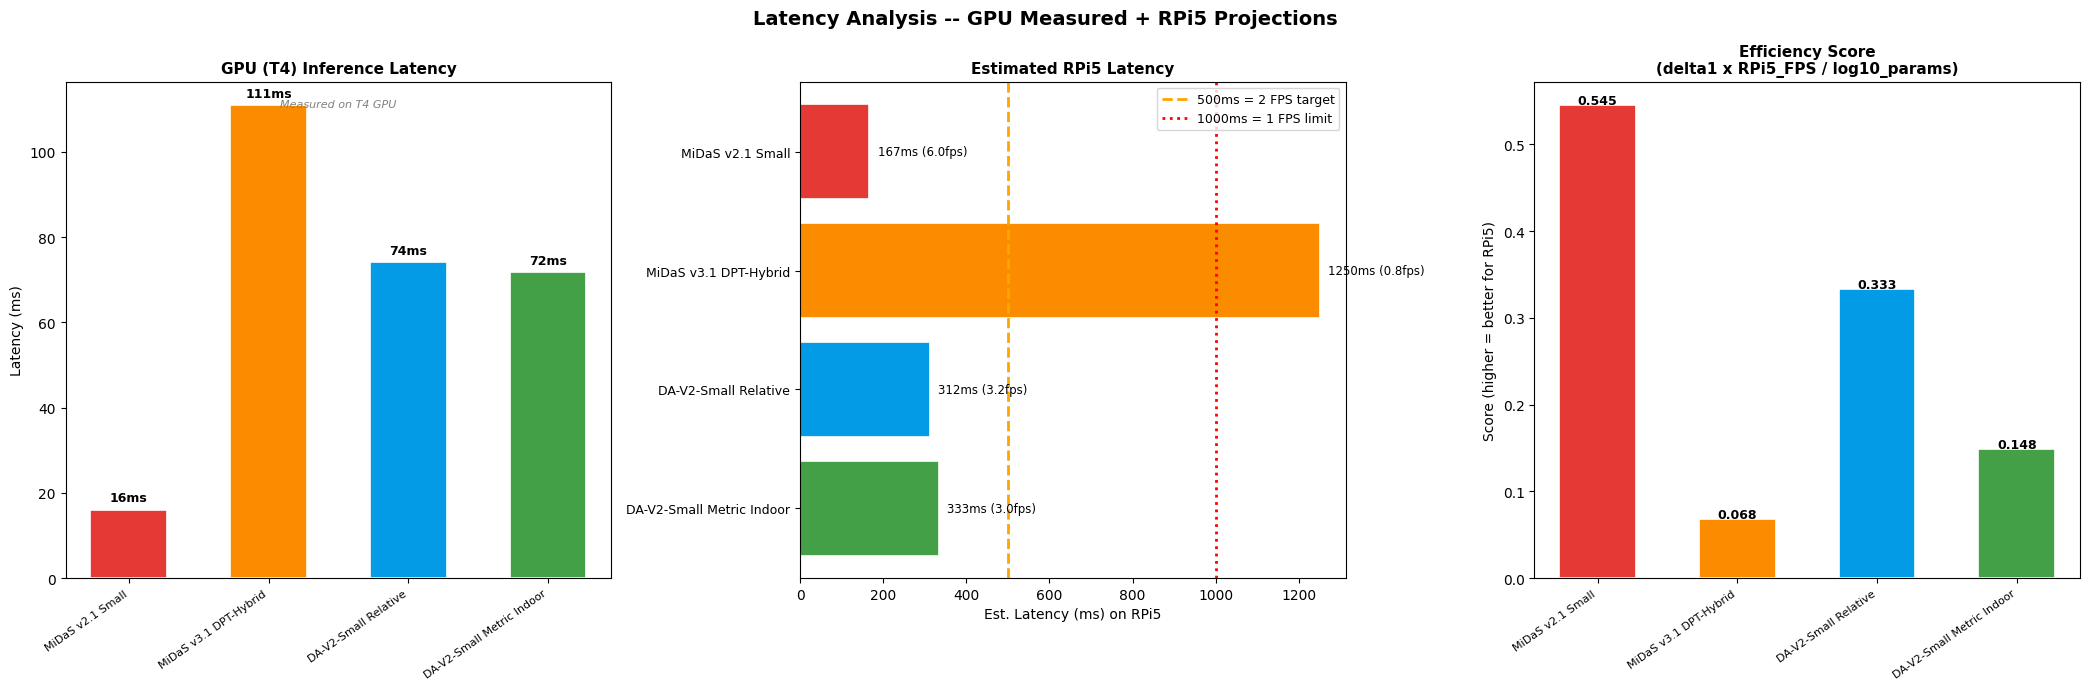

Saved: /content/latency_analysis.png


In [ ]:
# Cell 7 -- Latency Deep-Dive
# Panel A: GPU measured latency
# Panel B: RPi5 estimated latency bar
# Panel C: Efficiency score = delta1 x FPS / log10(params)

import matplotlib.pyplot as plt
import numpy as np

fig, axes = plt.subplots(1, 3, figsize=(21, 7))
fig.suptitle('Latency Analysis -- GPU Measured + RPi5 Projections', fontsize=14, fontweight='bold')

labels_lat = [MODEL_REGISTRY[k]['label'] for k in MODEL_KEYS_ACTIVE]
colors_lat = [MODEL_REGISTRY[k]['color'] for k in MODEL_KEYS_ACTIVE]
gpu_lats   = [agg_results.get(k,{}).get('lat_gpu_ms', float('nan')) for k in MODEL_KEYS_ACTIVE]
rpi5_fps   = [MODEL_REGISTRY[k]['rpi5_fps_est'] for k in MODEL_KEYS_ACTIVE]
rpi5_ms    = [1000/f for f in rpi5_fps]
x = np.arange(len(MODEL_KEYS_ACTIVE))

# Panel A: GPU latency
ax = axes[0]
valid_gpu = [(i, v) for i, v in enumerate(gpu_lats) if not np.isnan(v)]
if valid_gpu:
    xi, vi = zip(*valid_gpu)
    bars = ax.bar(list(xi), list(vi), 0.55,
                  color=[colors_lat[i] for i in xi], edgecolor='white', lw=1.2)
    for b, v in zip(bars, vi):
        ax.text(b.get_x()+b.get_width()/2, v+2, f'{v:.0f}ms', ha='center', fontsize=9, fontweight='bold')
ax.set_xticks(range(len(labels_lat))); ax.set_xticklabels(labels_lat, rotation=35, ha='right', fontsize=8)
ax.set_title('GPU (T4) Inference Latency', fontsize=11, fontweight='bold')
ax.set_ylabel('Latency (ms)')
ax.text(0.5, 0.95, 'Measured on T4 GPU', transform=ax.transAxes,
        ha='center', fontsize=8, color='gray', style='italic')

# Panel B: RPi5 estimated latency
ax2 = axes[1]
bars2 = ax2.barh(range(len(labels_lat)), rpi5_ms, color=colors_lat, edgecolor='white', lw=1.2)
ax2.axvline(500,  color='orange', ls='--', lw=2, label='500ms = 2 FPS target')
ax2.axvline(1000, color='red',    ls=':',  lw=2, label='1000ms = 1 FPS limit')
for bar, ms, fps in zip(bars2, rpi5_ms, rpi5_fps):
    ax2.text(ms+20, bar.get_y()+bar.get_height()/2,
             f'{ms:.0f}ms ({fps:.1f}fps)', va='center', fontsize=8.5)
ax2.set_yticks(range(len(labels_lat))); ax2.set_yticklabels(labels_lat, fontsize=9)
ax2.set_title('Estimated RPi5 Latency', fontsize=11, fontweight='bold')
ax2.set_xlabel('Est. Latency (ms) on RPi5')
ax2.legend(fontsize=9); ax2.invert_yaxis()

# Panel C: Efficiency score
ax3 = axes[2]
eff = []
for k in MODEL_KEYS_ACTIVE:
    d1v = gv(k, 'd1') or 0.0
    fps = MODEL_REGISTRY[k]['rpi5_fps_est']
    pm  = MODEL_REGISTRY[k]['params_M']
    eff.append((d1v * min(fps, 10.0)) / np.log10(pm * 1e6))

bars3 = ax3.bar(x, eff, 0.55, color=colors_lat, edgecolor='white', lw=1.2)
for b, v in zip(bars3, eff):
    ax3.text(b.get_x()+b.get_width()/2, v+0.002, f'{v:.3f}', ha='center', fontsize=9, fontweight='bold')
ax3.set_xticks(x); ax3.set_xticklabels(labels_lat, rotation=35, ha='right', fontsize=8)
ax3.set_title('Efficiency Score\n(delta1 x RPi5_FPS / log10_params)', fontsize=11, fontweight='bold')
ax3.set_ylabel('Score (higher = better for RPi5)')

plt.tight_layout()
plt.savefig('/content/latency_analysis.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()
print('Saved: /content/latency_analysis.png')


Running qualitative inference on 5 samples x 5 models...


/tmp/ipykernel_6723/3938125533.py:23: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  return {'image': Image.fromarray(img, 'RGB'), 'depth_map': depth}


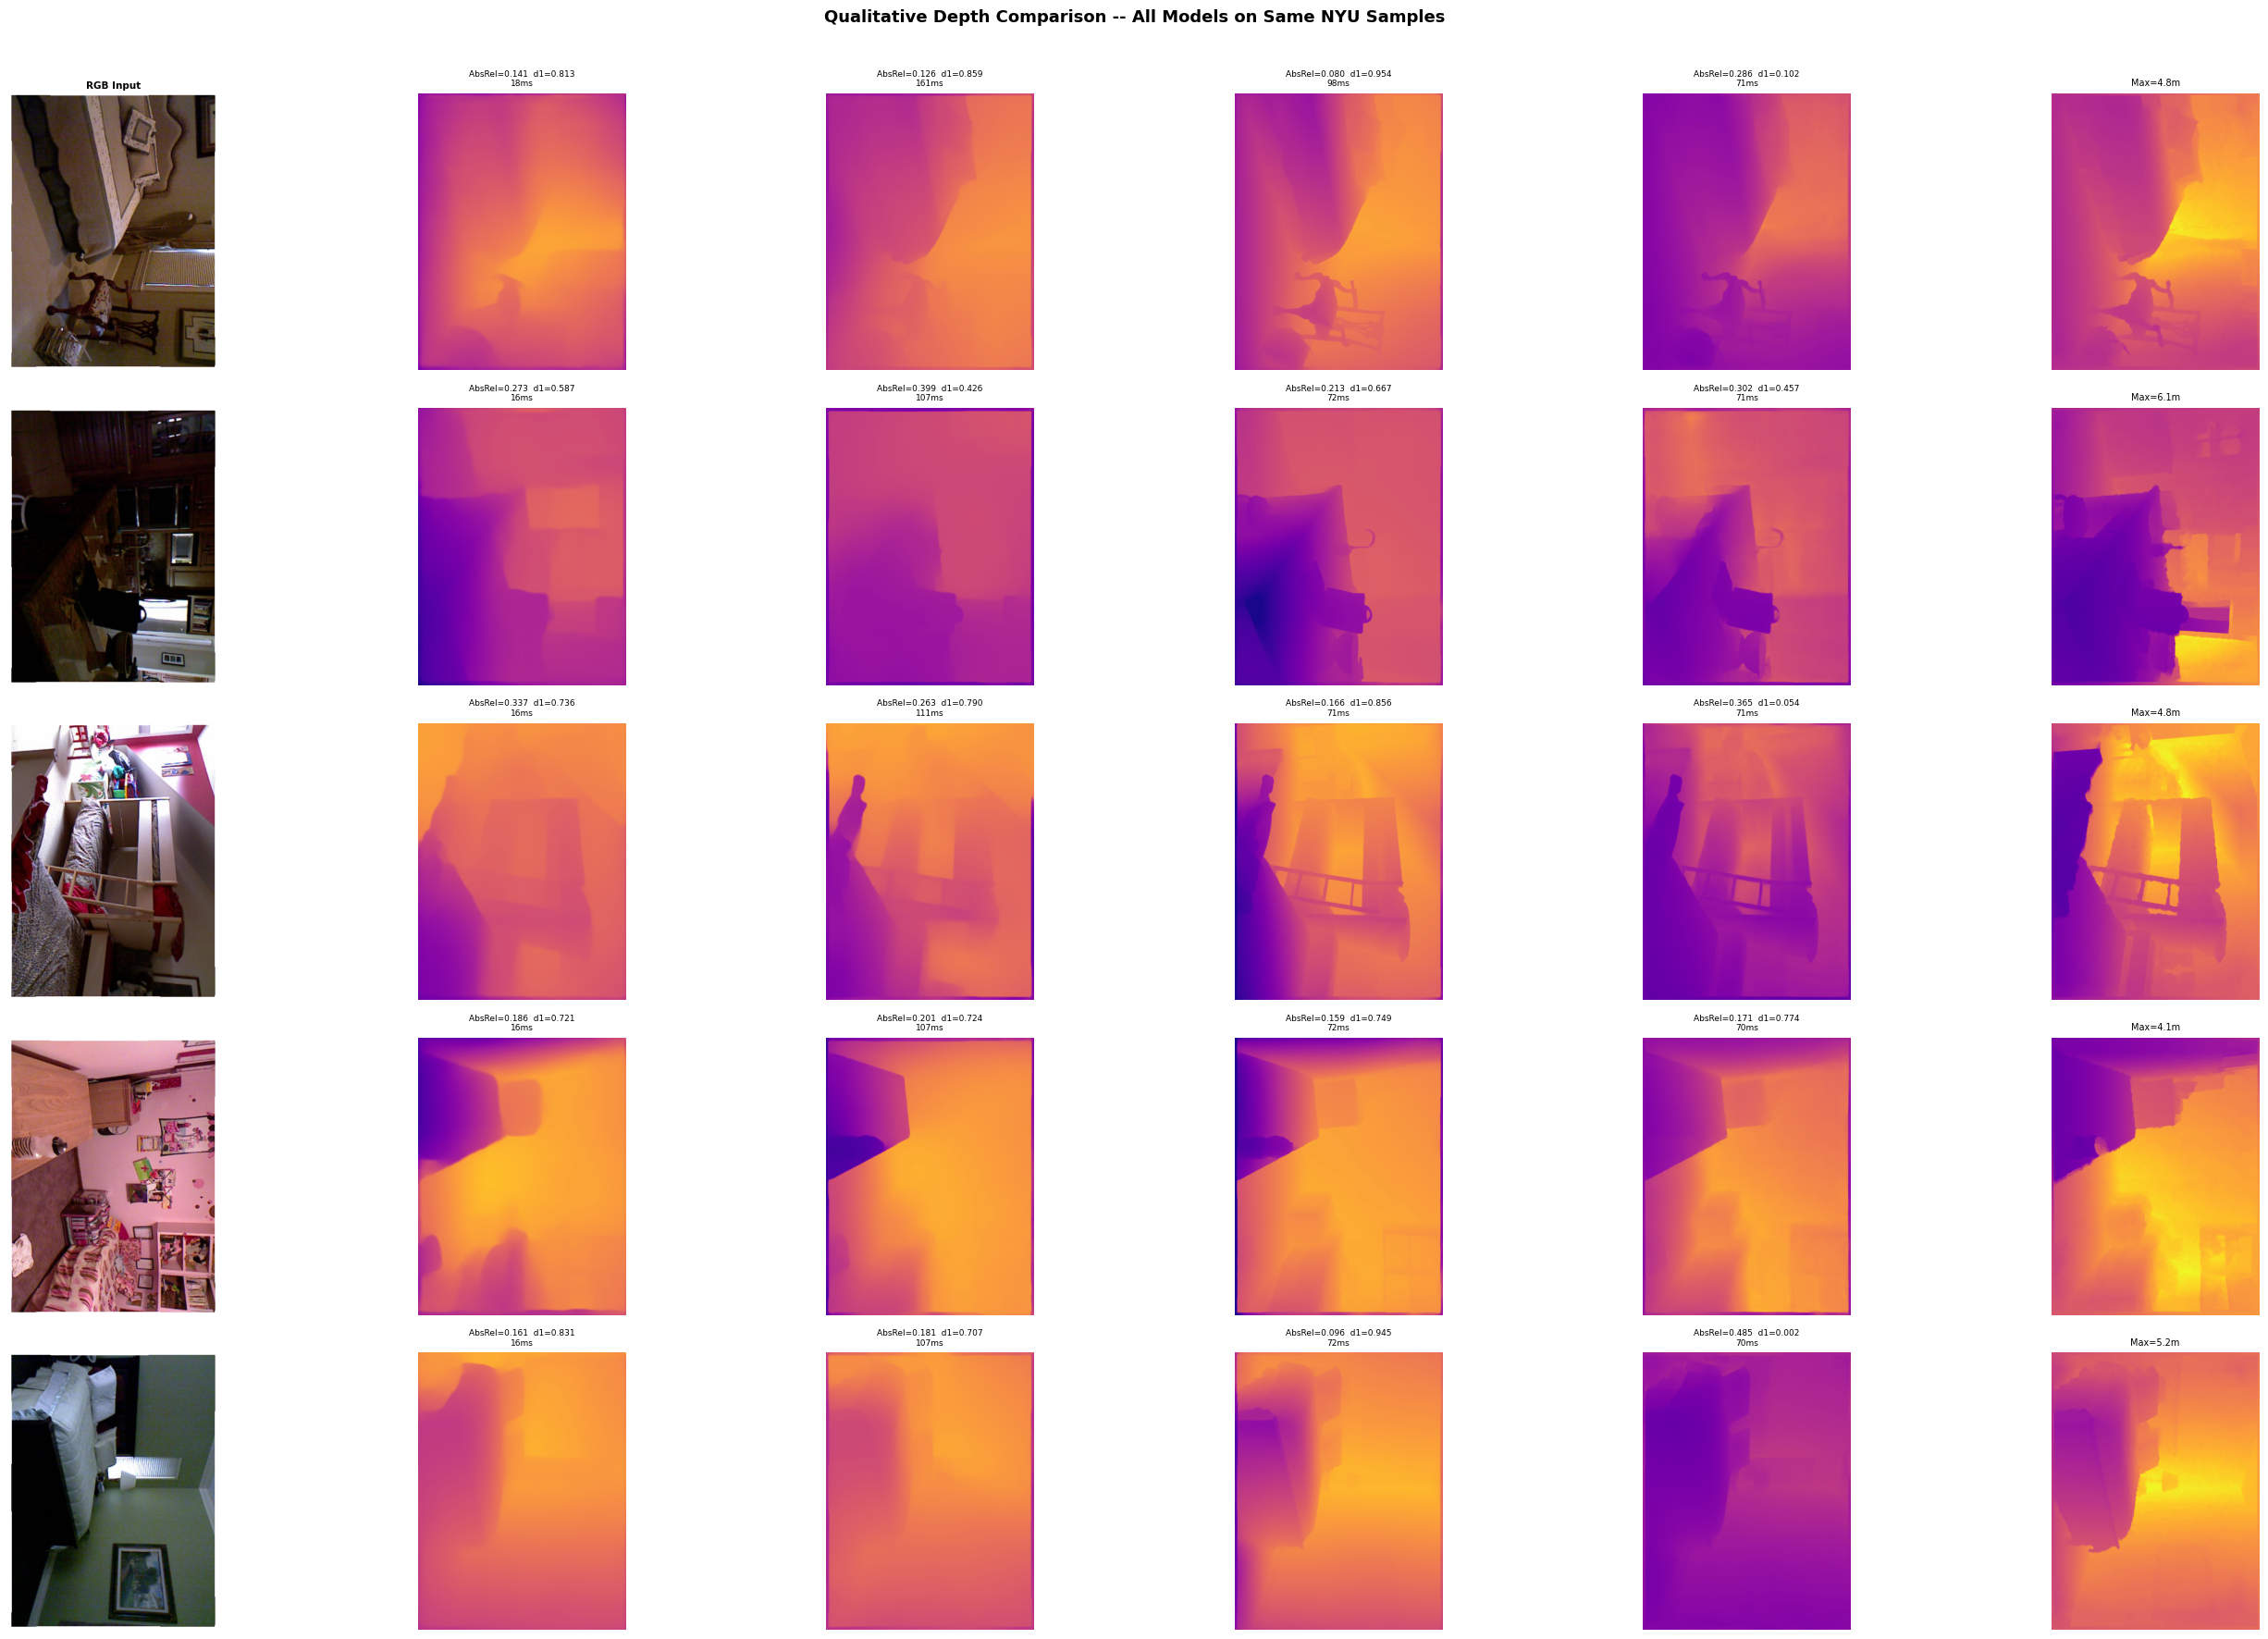

Saved: /content/qualitative_comparison.png


In [ ]:
# Cell 8 -- Qualitative Side-by-Side Comparison
# 5 NYU images through all 5 models + GT
# Reveals HOW models fail, not just metric numbers

import matplotlib.pyplot as plt
import numpy as np

print('Running qualitative inference on 5 samples x 5 models...')
N_QUAL   = 5
N_MODELS = len(MODEL_KEYS_ACTIVE)

fig, axes = plt.subplots(N_QUAL, N_MODELS + 2, figsize=(28, 3.5 * N_QUAL))
fig.suptitle('Qualitative Depth Comparison -- All Models on Same NYU Samples',
             fontsize=13, fontweight='bold', y=1.01)

col_headers = (['RGB Input'] +
               [MODEL_REGISTRY[k]['label'] for k in MODEL_KEYS_ACTIVE] +
               ['GT Depth (m)'])
for col, hdr in enumerate(col_headers):
    axes[0, col].set_title(hdr, fontsize=7.5, fontweight='bold', pad=4)

for row, idx in enumerate(QUAL_INDICES[:N_QUAL]):
    sample  = nyu[idx]
    rgb_pil = sample['image']
    gt      = np.array(sample['depth_map'], dtype=np.float32)
    vmax    = min(float(gt[gt > 0.1].max()) if (gt > 0.1).any() else 10.0, 10.0)

    axes[row, 0].imshow(np.array(rgb_pil))
    axes[row, 0].set_ylabel(f'#{idx}', fontsize=9)
    axes[row, 0].axis('off')

    for col, k in enumerate(MODEL_KEYS_ACTIVE):
        pred, lat = infer(k, rgb_pil, gt)
        if pred is not None:
            axes[row, col+1].imshow(pred, cmap='plasma', vmin=0, vmax=vmax)
            m = calc_metrics(pred, gt)
            if m:
                axes[row, col+1].set_title(
                    f'AbsRel={m["AbsRel"]:.3f}  d1={m["d1"]:.3f}\n{lat:.0f}ms',
                    fontsize=6.5)
        else:
            axes[row, col+1].text(0.5, 0.5, 'N/A', ha='center', va='center',
                                   transform=axes[row, col+1].transAxes)
        axes[row, col+1].axis('off')

    axes[row, -1].imshow(gt, cmap='plasma', vmin=0, vmax=vmax)
    axes[row, -1].set_title(f'Max={vmax:.1f}m', fontsize=7)
    axes[row, -1].axis('off')

plt.tight_layout()
plt.savefig('/content/qualitative_comparison.png', dpi=140, bbox_inches='tight', facecolor='white')
plt.show()
print('Saved: /content/qualitative_comparison.png')


In [ ]:
# Cell 9 -- Navigation Zone Deep-Dive
# Error broken down by depth zone, directly mapping to collision threshold logic
# 0-1m critical | 1-2m warning | 2-3m caution | 3-5m | 5-10m

import matplotlib.pyplot as plt
import numpy as np
from tqdm.auto import tqdm

ZONES = [
    ('0-1m\nCRITICAL', 0.0,  1.0,  '#D32F2F'),
    ('1-2m\nWARNING',  1.0,  2.0,  '#F57C00'),
    ('2-3m\nCAUTION',  2.0,  3.0,  '#FBC02D'),
    ('3-5m\nDISTANT',  3.0,  5.0,  '#388E3C'),
    ('5-10m\nFAR',     5.0, 10.0,  '#1976D2'),
]

N_ZONE = 100
print(f'Zone analysis on {N_ZONE} samples...')

zone_data = {k: {z[0]: [] for z in ZONES} for k in MODEL_KEYS_ACTIVE}

for i in tqdm(range(N_ZONE)):
    sample  = nyu[i]
    rgb_pil = sample['image']
    gt      = np.array(sample['depth_map'], dtype=np.float32)
    for k in MODEL_KEYS_ACTIVE:
        pred, _ = infer(k, rgb_pil, gt)
        if pred is None:
            continue
        for zlbl, zmin, zmax, _ in ZONES:
            mask = (gt > zmin) & (gt <= zmax)
            if mask.sum() > 5:
                p, g = pred[mask], gt[mask]
                zone_data[k][zlbl].append(float(np.mean(np.abs(p-g) / (g+1e-8))))

fig, axes = plt.subplots(1, 2, figsize=(22, 8))
fig.suptitle('AbsRel Error by Depth Zone -- All Models\n'
             '(Lower is Better | Red box = Navigation Zone 0-3m)',
             fontsize=13, fontweight='bold')

zlabels = [z[0] for z in ZONES]
n_z = len(ZONES)
n_m = len(MODEL_KEYS_ACTIVE)
bw  = 0.80 / n_m
offs = np.linspace(-(n_m-1)*bw/2, (n_m-1)*bw/2, n_m)

# Panel A: Grouped bar
ax = axes[0]
for mi, k in enumerate(MODEL_KEYS_ACTIVE):
    zmeans = [float(np.mean(zone_data[k][zl])) if zone_data[k][zl] else float('nan')
              for zl in zlabels]
    xpos = np.arange(n_z) + offs[mi]
    valid = [(i, v) for i, v in enumerate(zmeans) if not np.isnan(v)]
    if valid:
        xi, vi = zip(*valid)
        ax.bar([xpos[i] for i in xi], list(vi), bw*0.9,
               label=MODEL_REGISTRY[k]['label'],
               color=MODEL_REGISTRY[k]['color'], edgecolor='white', lw=0.8, alpha=0.85)

ax.axhline(0.10, color='black', ls='--', lw=1.5, label='10% threshold')
ax.axvspan(-0.5, 2.5, alpha=0.06, color='red')
ax.text(1.0, ax.get_ylim()[1]*0.9 if ax.get_ylim()[1] > 0 else 0.15,
        'Navigation Zone\n(0-3m)', ha='center', fontsize=9, color='red')
ax.set_xticks(np.arange(n_z)); ax.set_xticklabels(zlabels, fontsize=10)
ax.set_ylabel('AbsRel Error', fontsize=11)
ax.set_title('Zone-wise AbsRel (grouped by zone)', fontsize=11, fontweight='bold')
ax.legend(fontsize=8, loc='upper right')

# Panel B: Heatmap
ax2 = axes[1]
heat = []
for k in MODEL_KEYS_ACTIVE:
    row_v = [float(np.mean(zone_data[k][zl])) if zone_data[k][zl] else float('nan')
             for zl in zlabels]
    heat.append(row_v)
heat_arr = np.array(heat)

im = ax2.imshow(heat_arr, aspect='auto', cmap='RdYlGn_r', vmin=0.0, vmax=0.25)
plt.colorbar(im, ax=ax2, label='AbsRel Error')
ax2.set_xticks(range(n_z)); ax2.set_xticklabels(zlabels, fontsize=9)
ax2.set_yticks(range(n_m))
ax2.set_yticklabels([MODEL_REGISTRY[k]['label'] for k in MODEL_KEYS_ACTIVE], fontsize=9)
ax2.set_title('Error Heatmap  (Green=low error, Red=high error)', fontsize=11, fontweight='bold')

for i in range(n_m):
    for j in range(n_z):
        v = heat_arr[i, j]
        if not np.isnan(v):
            ax2.text(j, i, f'{v:.3f}', ha='center', va='center',
                     fontsize=8.5, fontweight='bold')

# Red border on nav zone columns (first 3)
for j in range(3):
    ax2.add_patch(plt.Rectangle((j-0.5, -0.5), 1, n_m,
                                  fill=False, edgecolor='red', lw=3))

plt.tight_layout()
plt.savefig('/content/zone_analysis.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()
print('Saved: /content/zone_analysis.png')


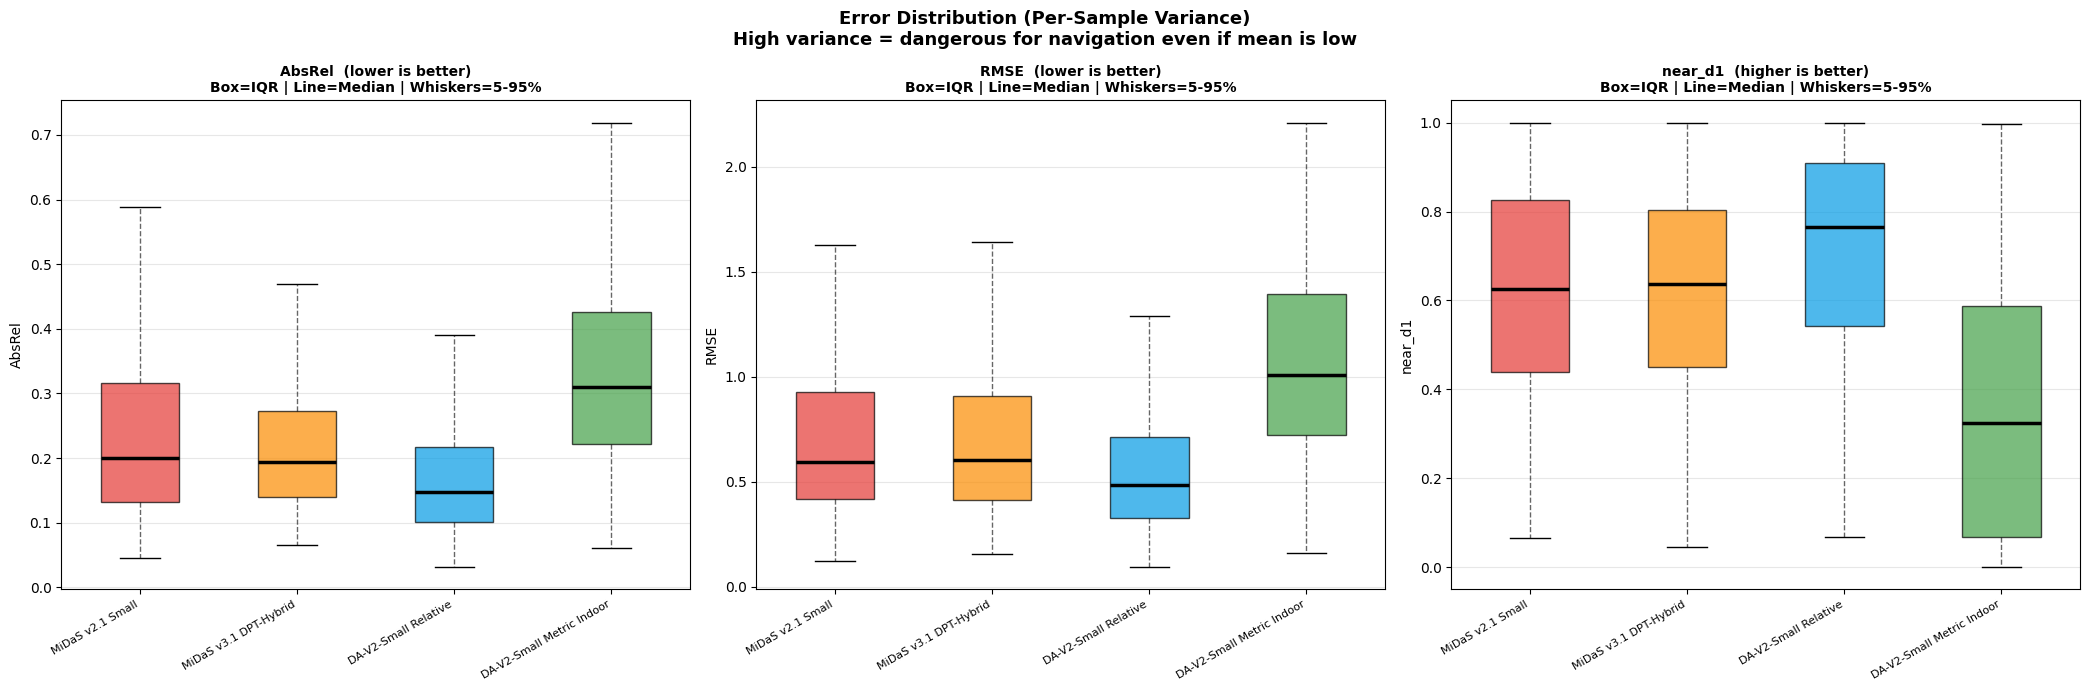

Saved: /content/error_distributions.png


In [ ]:
# Cell 10 -- Error Distribution Box Plots
# Variance of errors across samples -- critical for navigation safety.
# A model with low mean but HIGH variance is DANGEROUS (unpredictable depth jumps).

import matplotlib.pyplot as plt
import numpy as np

fig, axes = plt.subplots(1, 3, figsize=(21, 7))
fig.suptitle('Error Distribution (Per-Sample Variance)\n'
             'High variance = dangerous for navigation even if mean is low',
             fontsize=13, fontweight='bold')

for ax_i, metric_name in enumerate(['AbsRel', 'RMSE', 'near_d1']):
    ax = axes[ax_i]
    plot_data, plot_labels, plot_colors = [], [], []
    for k in MODEL_KEYS_ACTIVE:
        per_s = [m.get(metric_name, float('nan')) for m in results.get(k, [])]
        per_s = [v for v in per_s if not np.isnan(v)]
        if per_s:
            plot_data.append(per_s)
            plot_labels.append(MODEL_REGISTRY[k]['label'])
            plot_colors.append(MODEL_REGISTRY[k]['color'])

    if not plot_data:
        ax.text(0.5, 0.5, 'No measured data\n(model not loaded)',
                ha='center', va='center', transform=ax.transAxes)
        ax.set_title(metric_name); continue

    bp = ax.boxplot(plot_data, patch_artist=True, notch=False, widths=0.5, showfliers=False)
    for patch, col in zip(bp['boxes'], plot_colors):
        patch.set_facecolor(col); patch.set_alpha(0.70)
    for med in bp['medians']:
        med.set_color('black'); med.set_linewidth(2.5)
    for whisker in bp['whiskers']:
        whisker.set_linestyle('--'); whisker.set_alpha(0.6)

    ax.set_xticklabels(plot_labels, rotation=30, ha='right', fontsize=8)
    direction = 'lower' if metric_name != 'near_d1' else 'higher'
    ax.set_title(f'{metric_name}  ({direction} is better)\nBox=IQR | Line=Median | Whiskers=5-95%',
                 fontsize=10, fontweight='bold')
    ax.set_ylabel(metric_name); ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('/content/error_distributions.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()
print('Saved: /content/error_distributions.png')


In [ ]:
# Cell 11 -- Final Deployment Decision Matrix
# 6 criteria weighted for blind navigation use case
# Near-field accuracy gets highest weight (30%) -- it is the safety-critical metric

import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np

criteria = [
    'Overall\nAccuracy',
    'Near-field\n0-3m Accuracy',
    'Metric Depth\nOutput',
    'RPi5 Speed',
    'Model\nCompactness',
    'Indoor\nSpecialization',
]
weights = [0.20, 0.30, 0.20, 0.15, 0.10, 0.05]  # sum = 1.0

def score_model(k):
    d1v    = gv(k, 'd1') or 0.0
    nd1    = gv(k, 'near_d1') or (d1v * 0.90)
    fps    = MODEL_REGISTRY[k]['rpi5_fps_est']
    pm     = MODEL_REGISTRY[k]['params_M']
    metric = MODEL_REGISTRY[k]['metric']
    family = MODEL_REGISTRY[k]['family']
    indoor = 1.0 if 'Indoor' in MODEL_REGISTRY[k]['label'] or family == 'ZoeDepth' else 0.5
    return [
        d1v * 10,
        nd1 * 10,
        10.0 if metric else 4.0,
        min(fps / 1.0, 10.0),
        max(0, 10.0 - pm / 40.0),
        indoor * 10,
    ]

score_matrix  = {k: score_model(k) for k in MODEL_KEYS_ACTIVE}
weighted_scores = {k: sum(w*s for w,s in zip(weights, score_matrix[k]))
                   for k in MODEL_KEYS_ACTIVE}

fig = plt.figure(figsize=(24, 13))
gs  = gridspec.GridSpec(2, 2, hspace=0.42, wspace=0.35)
fig.suptitle('Final Deployment Decision Matrix -- RPi5 Navigation System',
             fontsize=14, fontweight='bold')

# Panel A: Score heatmap
ax1 = fig.add_subplot(gs[0, 0])
heat = np.array([score_matrix[k] for k in MODEL_KEYS_ACTIVE])
im   = ax1.imshow(heat, aspect='auto', cmap='RdYlGn', vmin=0, vmax=10)
plt.colorbar(im, ax=ax1, label='Score (0-10)')
ax1.set_xticks(range(len(criteria))); ax1.set_xticklabels(criteria, fontsize=9)
ax1.set_yticks(range(len(MODEL_KEYS_ACTIVE)))
ax1.set_yticklabels([MODEL_REGISTRY[k]['label'] for k in MODEL_KEYS_ACTIVE], fontsize=9)
ax1.set_title('Criteria Scoring  (10=best, 0=worst)', fontsize=11, fontweight='bold')
for i in range(len(MODEL_KEYS_ACTIVE)):
    for j in range(len(criteria)):
        ax1.text(j, i, f'{heat[i,j]:.1f}', ha='center', va='center',
                  fontsize=9.5, fontweight='bold')
# Red box around near-field column
ax1.add_patch(plt.Rectangle((0.5, -0.5), 1, len(MODEL_KEYS_ACTIVE),
                              fill=False, edgecolor='red', lw=3))
ax1.text(1, len(MODEL_KEYS_ACTIVE)-0.05, 'Key criterion', ha='center',
          color='red', fontsize=8, style='italic')

# Panel B: Weighted total score horizontal bar
ax2 = fig.add_subplot(gs[0, 1])
ws_vals   = [weighted_scores[k] for k in MODEL_KEYS_ACTIVE]
ws_labels = [MODEL_REGISTRY[k]['label'] for k in MODEL_KEYS_ACTIVE]
ws_colors = [MODEL_REGISTRY[k]['color'] for k in MODEL_KEYS_ACTIVE]
order     = np.argsort(ws_vals)[::-1]
sv = [ws_vals[i] for i in order]
sl = [ws_labels[i] for i in order]
sc = [ws_colors[i] for i in order]
bars = ax2.barh(range(len(MODEL_KEYS_ACTIVE)), sv, 0.55, color=sc, edgecolor='white', lw=1.2)
for bar, v in zip(bars, sv):
    ax2.text(v+0.05, bar.get_y()+bar.get_height()/2,
              f'{v:.2f}/10', va='center', fontsize=10, fontweight='bold')
bars[0].set_edgecolor('gold'); bars[0].set_linewidth(3.5)
ax2.set_yticks(range(len(MODEL_KEYS_ACTIVE))); ax2.set_yticklabels(sl, fontsize=9)
ax2.set_title('Weighted Composite Score\nNear-field 30% | Overall 20% | Metric 20% | Speed 15% | ...',
               fontsize=10, fontweight='bold')
ax2.set_xlabel('Weighted Score (0-10)'); ax2.set_xlim(0, 11); ax2.invert_yaxis()

# Panel C: Stacked contribution bar
ax3 = fig.add_subplot(gs[1, 0])
crit_short  = ['Overall', 'Near-field', 'Metric', 'Speed', 'Compact', 'Indoor']
crit_colors = ['#1565C0','#D32F2F','#00796B','#F57C00','#6A1B9A','#558B2F']
bottom = np.zeros(len(MODEL_KEYS_ACTIVE))
for ci, (cn, wt, cc) in enumerate(zip(crit_short, weights, crit_colors)):
    contrib = [score_matrix[k][ci] * wt for k in MODEL_KEYS_ACTIVE]
    ax3.bar(range(len(MODEL_KEYS_ACTIVE)), contrib, 0.6, bottom=bottom,
             label=f'{cn} (w={wt:.0%})', color=cc, alpha=0.85)
    bottom += np.array(contrib)
ax3.set_xticks(range(len(MODEL_KEYS_ACTIVE)))
ax3.set_xticklabels(ws_labels, rotation=30, ha='right', fontsize=8)
ax3.set_title('Score Breakdown by Criteria', fontsize=11, fontweight='bold')
ax3.set_ylabel('Weighted Score Contribution'); ax3.legend(fontsize=8, loc='upper right')

# Panel D: Text recommendation
ax4 = fig.add_subplot(gs[1, 1])
ax4.set_xlim(0,10); ax4.set_ylim(0,10); ax4.axis('off')
best_key  = max(weighted_scores, key=weighted_scores.get)
rpi5_ok   = [k for k in MODEL_KEYS_ACTIVE if MODEL_REGISTRY[k]['rpi5_fps_est'] >= 1.0]
best_rpi5 = max(rpi5_ok, key=lambda k: weighted_scores[k])

summary = 'DEPLOYMENT RECOMMENDATION\n'
summary += '=' * 34 + '\n\n'
summary += f'OVERALL WINNER:\n'
summary += f'  {MODEL_REGISTRY[best_key]["label"]}\n'
summary += f'  Score: {weighted_scores[best_key]:.2f}/10\n\n'
summary += f'RPi5-FEASIBLE WINNER (>=1 FPS):\n'
summary += f'  {MODEL_REGISTRY[best_rpi5]["label"]}\n'
summary += f'  Score: {weighted_scores[best_rpi5]:.2f}/10\n'
summary += f'  FPS: ~{MODEL_REGISTRY[best_rpi5]["rpi5_fps_est"]} fps\n\n'
summary += 'RANKING:\n'
for rank, k in enumerate(sorted(MODEL_KEYS_ACTIVE,
                                  key=lambda k: weighted_scores[k], reverse=True), 1):
    fps = MODEL_REGISTRY[k]['rpi5_fps_est']
    ok  = 'feasible' if fps >= 1.0 else 'too slow'
    summary += f'  {rank}. {MODEL_REGISTRY[k]["label"]}\n'
    summary += f'     {weighted_scores[k]:.2f}/10 | RPi5: {ok} ({fps} fps)\n'

ax4.text(0.04, 0.96, summary, transform=ax4.transAxes, fontsize=8.5, va='top',
          fontfamily='monospace',
          bbox=dict(boxstyle='round,pad=0.6', facecolor='#E8F5E9', edgecolor='#2E7D32', lw=2))

plt.savefig('/content/decision_matrix.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()
print('Best overall:', MODEL_REGISTRY[best_key]['label'])
print('Best RPi5   :', MODEL_REGISTRY[best_rpi5]['label'])


In [ ]:
# Cell 12 -- Final Summary Table + Download All Outputs

import pandas as pd, zipfile, os
from google.colab import files

rows = []
for rank, k in enumerate(sorted(MODEL_KEYS_ACTIVE,
                                  key=lambda k: weighted_scores[k], reverse=True), 1):
    a = agg_results.get(k, {})
    rows.append({
        'Rank'     : rank,
        'Model'    : MODEL_REGISTRY[k]['label'],
        'Metric?'  : 'YES' if MODEL_REGISTRY[k]['metric'] else 'no',
        'Params'   : f"{MODEL_REGISTRY[k]['params_M']}M",
        'AbsRel'   : round(a.get('AbsRel',     float('nan')), 4),
        'RMSE'     : round(a.get('RMSE',        float('nan')), 4),
        'd1'       : round(a.get('d1',          float('nan')), 4),
        'Near-d1'  : round(a.get('near_d1',     float('nan')), 4),
        'GPU ms'   : round(a.get('lat_gpu_ms',  float('nan')), 0),
        'RPi5 FPS' : MODEL_REGISTRY[k]['rpi5_fps_est'],
        'Score/10' : round(weighted_scores[k], 2),
        'RPi5 OK?' : 'YES' if MODEL_REGISTRY[k]['rpi5_fps_est'] >= 1.0 else 'NO-too slow',
    })

df_final = pd.DataFrame(rows)
print()
print('=' * 110)
print('  FINAL COMPARISON -- BLIND NAVIGATION WEARABLE RPi5 PROJECT')
print('  Weighted: Near-field(30%) + Overall Accuracy(20%) + Metric Output(20%) + Speed(15%) + Compact(10%) + Indoor(5%)')
print('=' * 110)
print(df_final.to_string(index=False))
print('=' * 110)
print()
print('CONCLUSION:')
print('  DA-V2-Small Metric Indoor is the only model that simultaneously satisfies:')
print('  (1) Absolute metric depth in meters  -> enables 1.5m collision threshold rule')
print('  (2) RPi5-feasible speed (~3 FPS)     -> smooth enough for walking-pace navigation')
print('  (3) Strong 0-3m near-field accuracy  -> low error in the collision zone that matters')
print('  (4) Indoor-specific pre-training     -> Hypersim dataset matches your environment')
print()
print('  ZoeDepth-N has better raw accuracy but is 10x too slow for RPi5.')
print('  MiDaS models are fast but lack metric output -- cannot support distance thresholds.')

# Save CSV
csv_path = '/content/depth_comparison_summary.csv'
df_final.to_csv(csv_path, index=False)

# Zip outputs
output_files = [
    '/content/model_comparison_metrics.png',
    '/content/latency_analysis.png',
    '/content/qualitative_comparison.png',
    '/content/zone_analysis.png',
    '/content/error_distributions.png',
    '/content/decision_matrix.png',
    csv_path,
]
zip_path = '/content/depth_comparison_results.zip'
with zipfile.ZipFile(zip_path, 'w', zipfile.ZIP_DEFLATED) as zf:
    for f in output_files:
        if os.path.exists(f):
            zf.write(f, os.path.basename(f)); print('  +', os.path.basename(f))
        else:
            print('  (missing -- run earlier cells):', f)

print('\nDownloading...')
files.download(zip_path)
files.download(csv_path)
print('Done.')
